Part 1:

1. Load the dataset and preprocess the reviews.
a. Convert all text to lowercase.
b. Remove non-alphabetic characters (punctuation).
c. Tokenize the reviews and remove common stopwords.
d. Apply stemming to reduce words to their root form.


2. Split the dataset into training and testing sets (80% training, 20% testing).


3. Use a Naive Bayes classifier to classify the reviews into positive and negative categories.
a. Implement a Bag-of-Words model using CountVectorizer.
b. Train the Naive Bayes classifier using the training set.

In [4]:
#Task 1: Load IMDB and preprocess reviews
import re
import pandas as pd
try:
    import nltk
    from nltk.corpus import stopwords
    from nltk.stem import PorterStemmer
    stopwords = set(stopwords.words("english"))
except Exception:
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
    stopwords = set(ENGLISH_STOP_WORDS)
    from nltk.stem import PorterStemmer
ps = PorterStemmer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stopwords]
    stems = [ps.stem(t) for t in tokens]
    return " ".join(stems)

imdb_path = "IMDB Dataset.csv"

df = pd.read_csv(imdb_path)

if 'review' not in df.columns:
    for c in df.columns:
        if 'review' in c.lower() or 'text' in c.lower():
            df.rename(columns={c: 'review'}, inplace=True)
if 'sentiment' not in df.columns:
    for c in df.columns:
        if 'label' in c.lower() or 'sentiment' in c.lower():
            df.rename(columns={c: 'sentiment'}, inplace=True)

df = df.dropna(subset=['review','sentiment'])
#normalize labels to 0/1
if df['sentiment'].dtype == object:
    df['sentiment'] = df['sentiment'].str.lower().map({'positive':1, 'pos':1, 'negative':0, 'neg':0})
df['sentiment'] = df['sentiment'].astype(int)

#preprocess (may take time on large data)
df = df.sample(2000, random_state=42)  # just 2k rows for testing
df['clean_review'] = df['review'].apply(preprocess_text)

#Save or show sample
print("Total rows:", len(df))
print(df[['review','clean_review','sentiment']].head(4))



Total rows: 2000
                                                  review  \
33553  I really liked this Summerslam due to the look...   
9427   Not many television shows appeal to quite as m...   
199    The film quickly gets to a major chase scene w...   
12447  Jane Austen would definitely approve of this o...   

                                            clean_review  sentiment  
33553  realli like summerslam look arena curtain just...          1  
9427   televis show appeal quit differ kind fan like ...          1  
199    film quickli get major chase scene increas des...          0  
12447  jane austen definit approv br br gwyneth paltr...          1  


Part 2:

1. Evaluate the performance of the model using the following metrics:
a. Accuracy
b. Precision, Recall, and F1-score
c. Confusion Matrix
d. ROC-AUC Score

=== MultinomialNB (IMDB) ===
Accuracy: 0.8025
Precision: 0.8187
Recall: 0.7641
F1-score: 0.7905
ROC-AUC: 0.8684
Confusion Matrix:
 [[172  33]
 [ 46 149]]


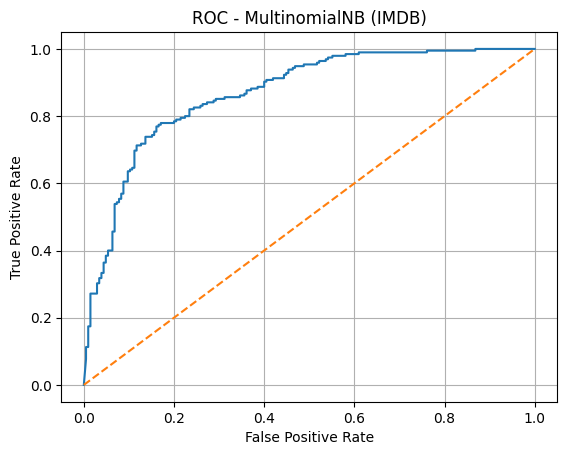

In [5]:
#Task 2: Train Naive Bayes on preprocessed IMDB data and evaluate
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

#Ensure 'clean_review' and 'sentiment' exist
assert 'clean_review' in df.columns and 'sentiment' in df.columns

X = df['clean_review']
y = df['sentiment']
#80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#Bag-of-Words
vec = CountVectorizer(max_features=20000)
X_train_bow = vec.fit_transform(X_train)
X_test_bow = vec.transform(X_test)
#Multinomial Naive Bayes
clf = MultinomialNB()
clf.fit(X_train_bow, y_train)
y_pred = clf.predict(X_test_bow)
y_proba = clf.predict_proba(X_test_bow)[:,1]
#Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
print("=== MultinomialNB (IMDB) ===")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print("Confusion Matrix:\n", cm)
#ROC plot
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - MultinomialNB (IMDB)")
plt.grid(True)
plt.show()


3 Feature Selection Exercise.

3.1 Feature Selection using Wrapper Methods.
Dataset: Breast Cancer Prognostic Dataset


Objective
You are tasked with identifying the most important features in predicting breast cancer prognosis using the
Breast Cancer Prognostic Dataset from the UCI Machine Learning Repository. Apply a wrapper method
(Recursive Feature Elimination) to select the best features and evaluate your model’s performance.


Part 1: Data Loading and Preprocessing
1. Load the Breast Cancer Prognostic Dataset.
2. Dataset is available in Drive.
3. Perform basic exploratory data analysis (EDA) to understand the dataset:
• Summarize key statistics for each feature.
• Check for missing values and handle them appropriately.
4. Split the dataset into training (80%) and testing (20%) sets.


Part 2: Apply a Wrapper Method
1. Use Recursive Feature Elimination (RFE) with a Logistic Regression model to perform feature selection:
• Select the top 5 features that contribute the most to predicting the target variable.
• Visualize the ranking of features.
2. Train the Logistic Regression model using only the selected features.


Part 3: Model Evaluation
1. Evaluate the model’s performance using the testing set:
• Metrics to calculate: Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
2. Compare the performance of the model trained on all features versus the model trained on the selected
features.


Part 4: Experiment
1. Experiment with different numbers of selected features (e.g., top 3, top 7).
2. Discuss how feature selection affects model performance.

Shape: (569, 30)
                         count        mean         std         min         25%
mean radius              569.0   14.127292    3.524049    6.981000   11.700000
mean texture             569.0   19.289649    4.301036    9.710000   16.170000
mean perimeter           569.0   91.969033   24.298981   43.790000   75.170000
mean area                569.0  654.889104  351.914129  143.500000  420.300000
mean smoothness          569.0    0.096360    0.014064    0.052630    0.086370
mean compactness         569.0    0.104341    0.052813    0.019380    0.064920
mean concavity           569.0    0.088799    0.079720    0.000000    0.029560
mean concave points      569.0    0.048919    0.038803    0.000000    0.020310
mean symmetry            569.0    0.181162    0.027414    0.106000    0.161900
mean fractal dimension   569.0    0.062798    0.007060    0.049960    0.057700
radius error             569.0    0.405172    0.277313    0.111500    0.232400
texture error            569.0    1

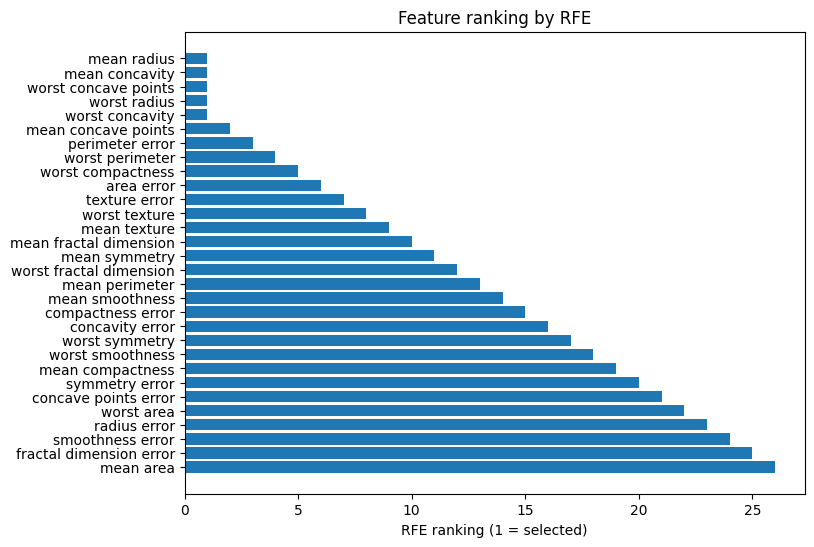

Performance on test set:
All features: {'accuracy': 0.9561, 'precision': 0.9589, 'recall': 0.9722, 'f1': 0.9655, 'roc_auc': np.float64(0.9957)}
Top-5 features: {'accuracy': 0.9474, 'precision': 0.9342, 'recall': 0.9861, 'f1': 0.9595, 'roc_auc': np.float64(0.9871)}
Top-3 features (3): ['mean concavity', 'worst radius', 'worst concavity']
Metrics top-3: {'accuracy': 0.9474, 'precision': 0.9459, 'recall': 0.9722, 'f1': 0.9589, 'roc_auc': np.float64(0.9851)}
Top-7 features (7): ['mean radius', 'mean concavity', 'mean concave points', 'perimeter error', 'worst radius', 'worst concavity', 'worst concave points']
Metrics top-7: {'accuracy': 0.9474, 'precision': 0.9459, 'recall': 0.9722, 'f1': 0.9589, 'roc_auc': np.float64(0.9864)}


In [7]:
#Task 3: Feature Selection using RFE with Logistic Regression
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
#except:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

#Basic EDA
print("Shape:", X.shape)
print(X.describe().T.iloc[:,:5])
print("Missing values total:", X.isnull().sum().sum())

#Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#RFE to select top-5 features using Logistic Regression
lr = LogisticRegression(max_iter=10000, solver='liblinear')
rfe = RFE(estimator=lr, n_features_to_select=5)
rfe.fit(X_train, y_train)

selected = X.columns[rfe.support_].tolist()
ranking = pd.Series(rfe.ranking_, index=X.columns).sort_values()
print("Top-5 selected features:", selected)

#Plot ranking
plt.figure(figsize=(8,6))
plt.barh(ranking.index, ranking.values)
plt.xlabel("RFE ranking (1 = selected)")
plt.title("Feature ranking by RFE")
plt.gca().invert_yaxis()
plt.show()

#Train Logistic Regression on all features
lr_all = LogisticRegression(max_iter=10000, solver='liblinear')
lr_all.fit(X_train, y_train)
pred_all = lr_all.predict(X_test)
proba_all = lr_all.predict_proba(X_test)[:,1]

#Train Logistic Regression on selected features
lr_sel = LogisticRegression(max_iter=10000, solver='liblinear')
lr_sel.fit(X_train[selected], y_train)
pred_sel = lr_sel.predict(X_test[selected])
proba_sel = lr_sel.predict_proba(X_test[selected])[:,1]

def eval_metrics(y_true, y_pred, y_proba):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba)
    }

print("Performance on test set:")
print("All features:", {k: round(v,4) for k,v in eval_metrics(y_test, pred_all, proba_all).items()})
print("Top-5 features:", {k: round(v,4) for k,v in eval_metrics(y_test, pred_sel, proba_sel).items()})

#Experiment: top-3 and top-7
for k in [3,7]:
    rfe_k = RFE(estimator=lr, n_features_to_select=k)
    rfe_k.fit(X_train, y_train)
    feats_k = X.columns[rfe_k.support_].tolist()
    model_k = LogisticRegression(max_iter=10000, solver='liblinear')
    model_k.fit(X_train[feats_k], y_train)
    pred_k = model_k.predict(X_test[feats_k])
    proba_k = model_k.predict_proba(X_test[feats_k])[:,1]
    print(f"Top-{k} features ({len(feats_k)}):", feats_k)
    print(f"Metrics top-{k}:", {k2: round(v,4) for k2,v in eval_metrics(y_test, pred_k, proba_k).items()})
